# Exploración de abundancia taxonómica: CLR, datos crudos y escalado

Esta libreta compara PCA sobre tres representaciones de la misma tabla de
abundancia taxonómica: transformación CLR, abundancia sin transformar y
estandarización por característica. Las muestras se alinean explícitamente con
los metadatos y todos los productos se guardan en `results/`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from src.paths import DATASETS_DIR, analysis_output_dirs

ANALYSIS = "01_otu_eda"
OUTPUTS = analysis_output_dirs(ANALYSIS)
TABLES = OUTPUTS["tables"]
FIGURES = OUTPUTS["figures"]

OUTLIERS = [
    "37082_3#16", "37082_2#4", "37035_2#22",
    "37035_7#18", "36703_3#20", "36703_3#4",
]

## Carga y alineación de muestras

In [2]:
metadata = pd.read_csv(DATASETS_DIR / "latinbiota_sample_metadata.csv")
taxonomy = pd.read_csv(DATASETS_DIR / "bracken_taxonomy.csv", index_col=0).T
taxonomy = taxonomy.apply(pd.to_numeric, errors="coerce").fillna(0.0)
taxonomy = taxonomy.drop(index=OUTLIERS, errors="ignore")

lifestyle = metadata.drop_duplicates("Lane").set_index("Lane")["Lifestyle"]
lifestyle = lifestyle.reindex(taxonomy.index)
valid = lifestyle.isin(["Rural", "Urban"])
taxonomy = taxonomy.loc[valid].copy()
lifestyle = lifestyle.loc[valid].copy()

if taxonomy.empty or lifestyle.isna().any():
    raise ValueError("No fue posible alinear abundancias y estilos de vida.")

print("Tabla taxonómica:", taxonomy.shape)
print("Alineación completa:", taxonomy.index.equals(lifestyle.index))
lifestyle.value_counts()

Tabla taxonómica: (199, 13529)
Alineación completa: True


Lifestyle
Rural    117
Urban     82
Name: count, dtype: int64

## Transformaciones y PCA

In [3]:
def clr_transform(data, pseudocount=1e-6):
    if (data < 0).any().any():
        raise ValueError("CLR requiere abundancias no negativas.")
    log_values = np.log(data.astype(float) + pseudocount)
    return log_values.sub(log_values.mean(axis=1), axis=0)


def fit_two_component_pca(data, labels):
    clean = data.replace([np.inf, -np.inf], np.nan).dropna(axis=1)
    pca = PCA(n_components=2)
    scores = pd.DataFrame(
        pca.fit_transform(clean), index=clean.index, columns=["PC1", "PC2"]
    )
    scores["Lifestyle"] = labels.reindex(scores.index)
    return pca, scores


taxonomy_clr = clr_transform(taxonomy)
taxonomy_scaled = pd.DataFrame(
    StandardScaler().fit_transform(taxonomy),
    index=taxonomy.index,
    columns=taxonomy.columns,
)

representations = {
    "CLR": taxonomy_clr,
    "Sin transformación": taxonomy,
    "StandardScaler": taxonomy_scaled,
}
pca_results = {
    name: fit_two_component_pca(data, lifestyle)
    for name, data in representations.items()
}

for name, (pca, scores) in pca_results.items():
    print(
        f"{name}: PC1={pca.explained_variance_ratio_[0]:.2%}, "
        f"PC2={pca.explained_variance_ratio_[1]:.2%}, "
        f"total={pca.explained_variance_ratio_[:2].sum():.2%}"
    )

CLR: PC1=7.12%, PC2=3.72%, total=10.84%
Sin transformación: PC1=27.80%, PC2=11.15%, total=38.96%
StandardScaler: PC1=17.40%, PC2=5.94%, total=23.34%


## Comparación visual y productos

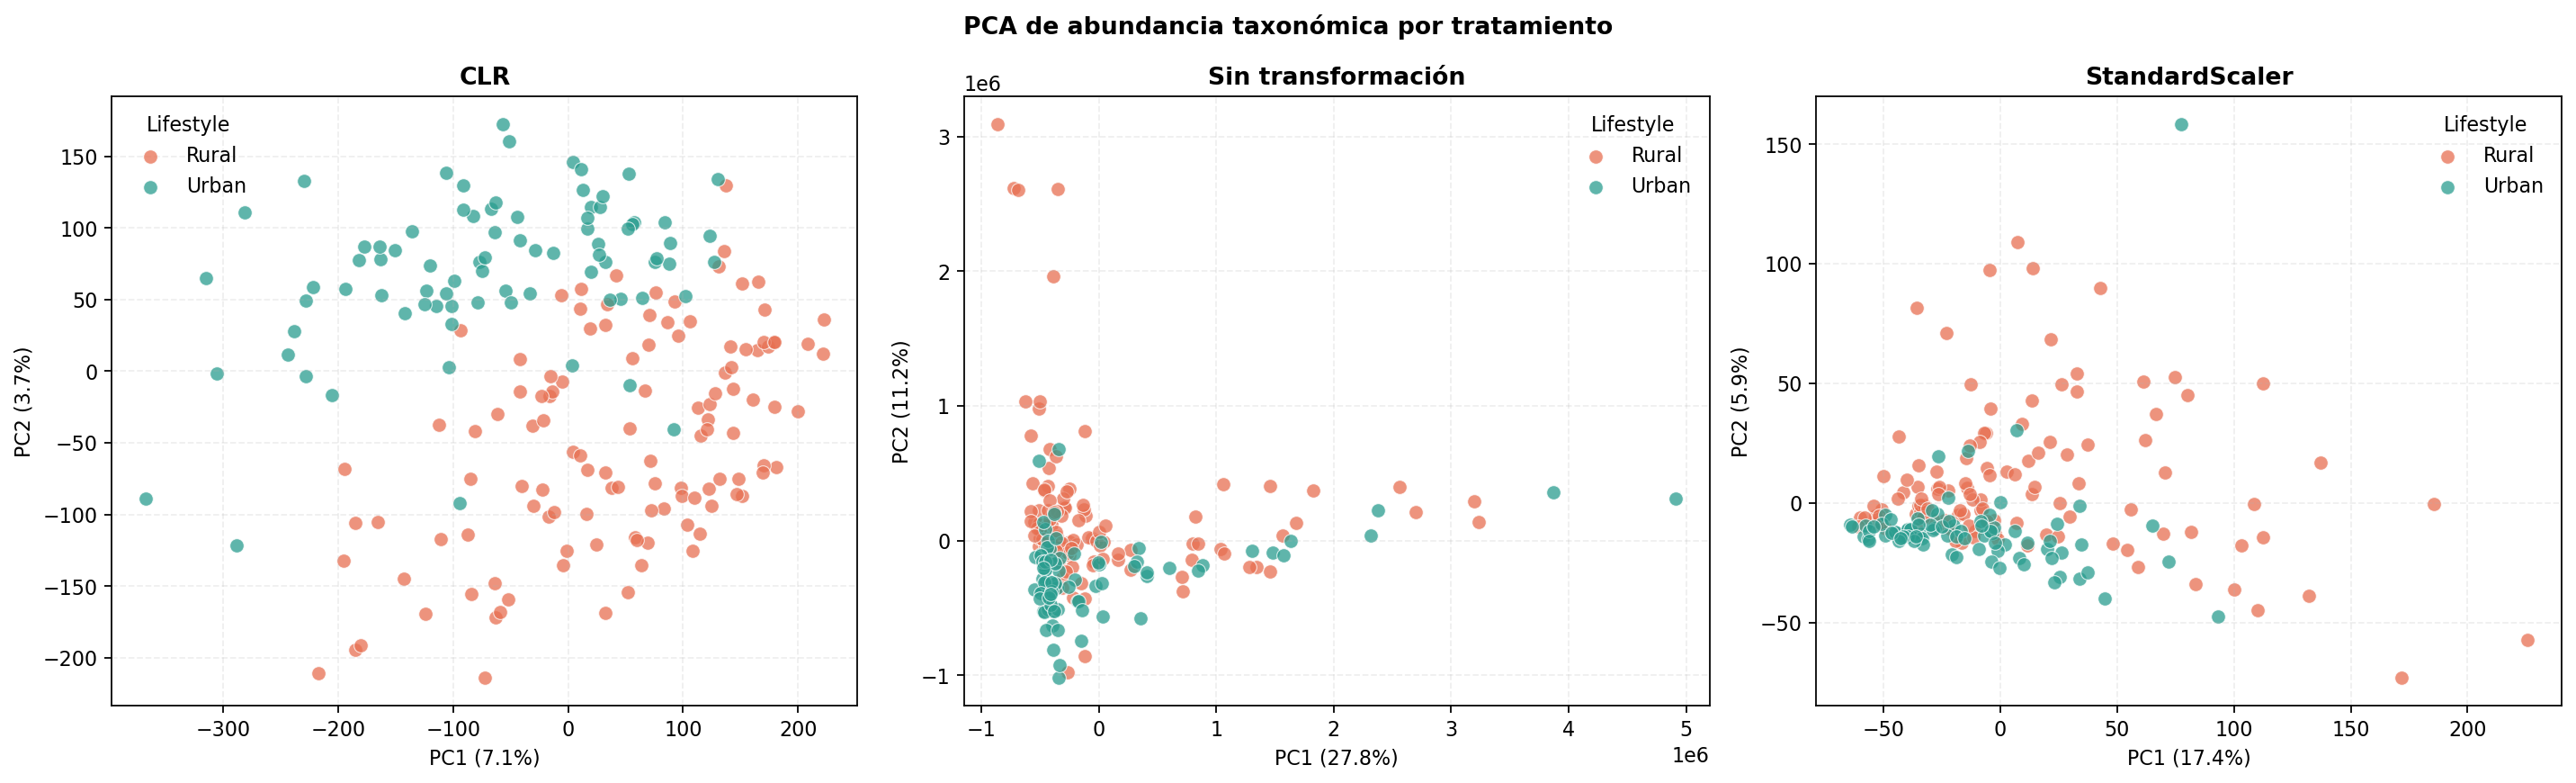

Figura: C:\Users\rafap\Documents\tesis_maestria\tesis_maestria - copia\results\figures\01_otu_eda\otu_pca_method_comparison.png
Tablas exportadas: 4


In [4]:
colors = {"Rural": "#e76f51", "Urban": "#2a9d8f"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=160)

for ax, (name, (pca, scores)) in zip(axes, pca_results.items()):
    for group in ["Rural", "Urban"]:
        points = scores.loc[scores["Lifestyle"].eq(group)]
        ax.scatter(
            points["PC1"], points["PC2"], label=group, color=colors[group],
            s=50, alpha=0.75, edgecolor="white", linewidth=0.5,
        )
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title(name, fontweight="bold")
    ax.grid(alpha=0.2, linestyle="--")
    ax.legend(title="Lifestyle", frameon=False)

fig.suptitle("PCA de abundancia taxonómica por tratamiento", fontweight="bold")
fig.tight_layout()
figure_path = FIGURES / "otu_pca_method_comparison.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

export_names = {
    "CLR": "otu_pca_scores_clr.csv",
    "Sin transformación": "otu_pca_scores_raw.csv",
    "StandardScaler": "otu_pca_scores_scaled.csv",
}
for name, filename in export_names.items():
    pca_results[name][1].to_csv(TABLES / filename)

pca_results["CLR"][1].to_csv(TABLES / "otu_pca_scores_with_lifestyle.csv")
print("Figura:", figure_path)
print("Tablas exportadas:", len(export_names) + 1)